In [1]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Setup

In [2]:
import numpy as np
import random
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import defaultdict
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import fit_2D, fit_2d_models_per_slice
from utils.loss_functions import ssim_L1_2d_loss
from models.alzheimers_cure_2d import VAE
from models.no_more_alzheimer_2d import UNet2D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [3]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


## One model for whole brain

### Load, Run and Save VAE

In [4]:
vae = VAE(latent_dim=64).to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-4, weight_decay=1e-2)

In [5]:
vae, vae_loss, vae_snapshots = fit_2D(
                            vae, 
                            optimizer,
                            device,
                            data_loader,
                            training_pairs, 
                            ssim_L1_2d_loss, 
                            epochs=500, 
                            save_every=250,
                            model_dir="out/vae_models",
                            model_name="2d_vae_model",
                            )

No model weights found at out/vae_models/2d_vae_model.pt. Starting with random weights.


Training 2D VAE Model on Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

Training 2D VAE Model on Epochs: 100%|██████████| 500/500 [26:28<00:00,  3.18s/it]


Saved model weights to out/vae_models/2d_vae_model.pt


### Load, Run and Save UNET

In [6]:
unet = UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)
optimizer = optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-2)

In [7]:
unet, unet_loss, unet_snapshots = fit_2D(
                            unet, 
                            optimizer,
                            device,
                            data_loader,
                            training_pairs, 
                            ssim_L1_2d_loss,  
                            epochs=500, 
                            save_every=250,
                            model_dir="out/unet_models",
                            model_name="2d_unet_model",
                            )

No model weights found at out/unet_models/2d_unet_model.pt. Starting with random weights.


Training 2D VAE Model on Epochs: 100%|██████████| 500/500 [13:13<00:00,  1.59s/it]

Saved model weights to out/unet_models/2d_unet_model.pt


### Display Results

Displaying comparison for iteration 0 (U-Net) vs 0 (VAE)


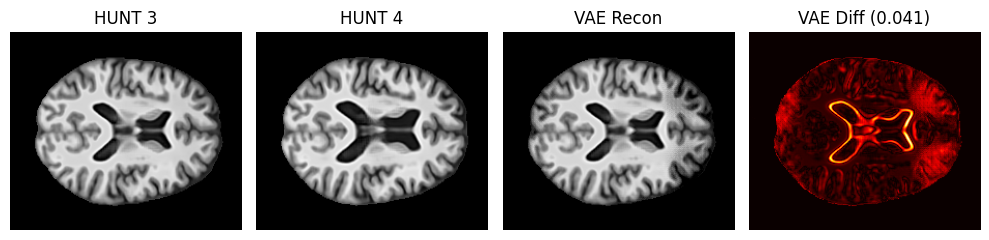

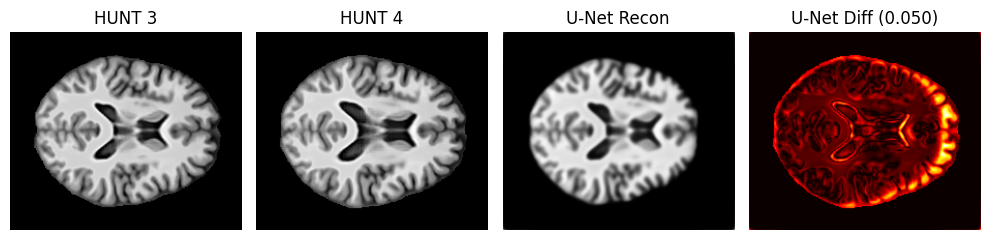

Displaying comparison for iteration 250 (U-Net) vs 250 (VAE)


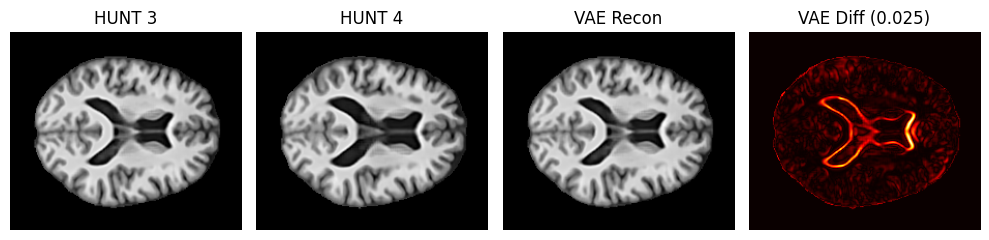

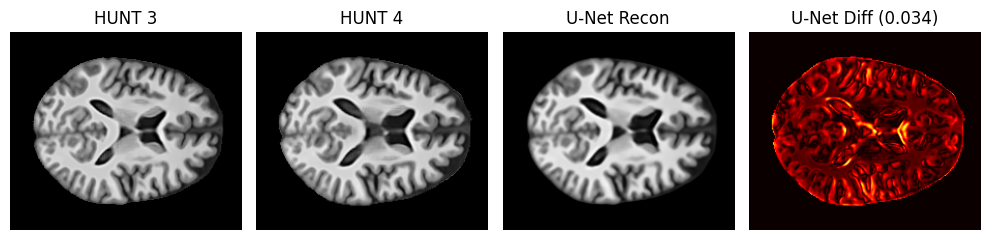

In [8]:
# Make sure both have the same number of snapshots
for unet_snap, vae_snap in zip(unet_snapshots, vae_snapshots):
    print(f"Displaying comparison for iteration {unet_snap['iter']} (U-Net) vs {vae_snap['iter']} (VAE)")

    # Compute absolute difference maps
    diff_unet = np.abs(unet_snap["recon"] - unet_snap["y"])
    diff_vae = np.abs(vae_snap["recon"] - vae_snap["y"])

    vae_slices = [vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae]
    unet_slices = [unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet]

    slices = [
        unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet,
        vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae
    ]

    unet_labels = ["HUNT 3", "HUNT 4", "U-Net Recon", f"U-Net Diff ({np.mean(diff_unet):.3f})"]
    vae_labels = ["HUNT 3", "HUNT 4", "VAE Recon", f"VAE Diff ({np.mean(diff_vae):.3f})"]
    
    colors = ["gray", "gray", "gray", "hot"]

    # Display slices on top of each other
    data_loader.display_slices(vae_slices, slice_labels=vae_labels, slice_colors=colors)
    data_loader.display_slices(unet_slices, slice_labels=unet_labels, slice_colors=colors)


## One model per Slice Index

Helper funcitons used so we can iterativly create models for each slice without loading every one into memory at once

In [9]:
# --- Constructors for model and optimizer ---
def vae_constructor():
    """Creates a new VAE instance"""
    return VAE(latent_dim=64).to(device)

def unet_constructor():
    """Creates a new UNET instance"""
    return UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)

def optimizer_constructor(model):
    """Creates a new optimizer for a given model."""
    return optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

### Load, Run and Save VAE models

In [10]:
slice_vae_loss, slice_vae_snapshots = fit_2d_models_per_slice(
    model_constructor=vae_constructor,            
    optimizer_constructor=optimizer_constructor,    
    device=device,
    dataLoader=data_loader,                         
    training_pairs=training_pairs,
    criterion=ssim_L1_2d_loss,                        
    epochs=500,  
    save_every=250,
    total_slices=193,
    crop_size=(192, 224),
    idx_to_show=93,
    model_dir="out/vae_models/multi",
    model_name_prefix="2d_vae_model",
    batch_size=97, # ~193/2
)

Training Slices: 100%|██████████| 2/2 [29:49<00:00, 894.77s/it]


### Load, Run and Save UNET Models

In [11]:
slice_unet_loss, slice_unet_snapshots = fit_2d_models_per_slice(
    model_constructor=unet_constructor,            
    optimizer_constructor=optimizer_constructor,    
    device=device,
    dataLoader=data_loader,                         
    training_pairs=training_pairs,
    criterion=ssim_L1_2d_loss,                      
    epochs=500,
    save_every=250,
    total_slices=193,
    crop_size=(192, 224),
    idx_to_show=93,
    model_dir="out/unet_models/multi",
    model_name_prefix="2d_unet_model",
    batch_size=97,
)

Training Slices: 100%|██████████| 2/2 [15:35<00:00, 467.76s/it]


### Display Results

Epoch 0: U-Net slice=93 | VAE slice=93


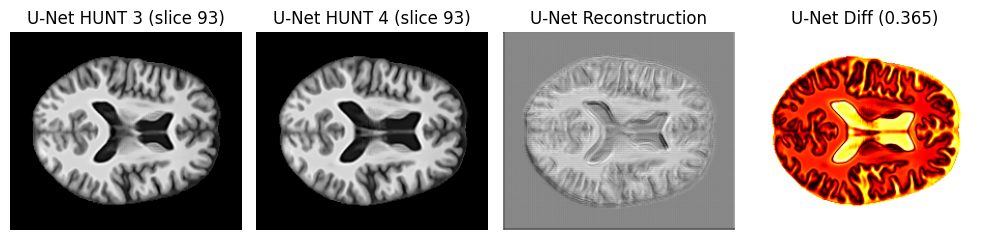

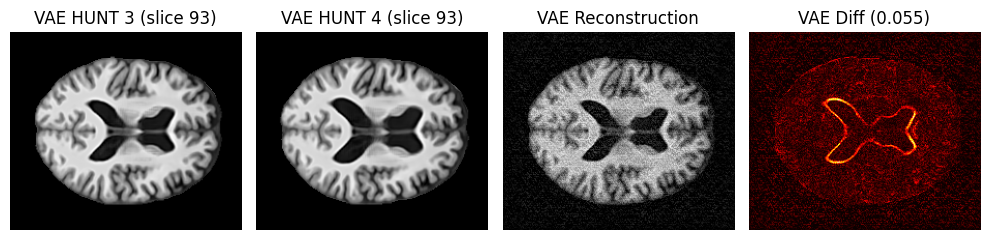

Epoch 250: U-Net slice=93 | VAE slice=93


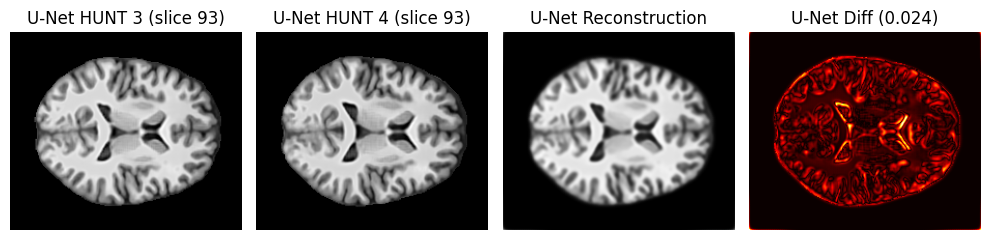

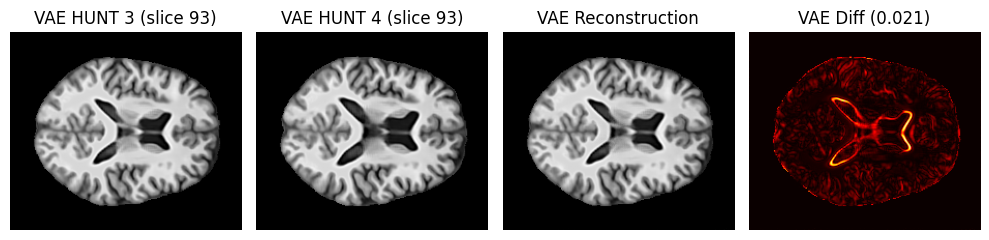

In [12]:
TOTAL_SLICES = 193

def _group_by_epoch_and_slice(snaps):
    """
    Returns: dict[epoch][slice_idx] -> snapshot
    If multiple snapshots exist for same (epoch, slice), keeps the last one.
    """
    by_ep = defaultdict(dict)
    for s in snaps:
        ep = s.get("iter", None)
        sl = s.get("slice_idx", None)
        if ep is None or sl is None:
            continue
        by_ep[ep][sl] = s
    return by_ep

# Use the outputs from fit_2d_models_per_slice
# vae_loss_history, vae_snapshots = ...
# unet_loss_history, unet_snapshots = ...

u_by = _group_by_epoch_and_slice(slice_unet_snapshots)
v_by = _group_by_epoch_and_slice(slice_vae_snapshots)

common_epochs = sorted(set(u_by.keys()) & set(v_by.keys()))
if not common_epochs:
    raise RuntimeError("No overlapping epochs between U-Net and VAE snapshots.")

for ep in common_epochs:
    # slices present in BOTH models at this epoch
    common_slices = sorted(set(u_by[ep].keys()) & set(v_by[ep].keys()))
    if not common_slices:
        print(f"Epoch {ep}: no common slice snapshots; skipping.")
        continue

    # pick a random common slice
    slice_idx = random.choice(common_slices)

    unet_snap = u_by[ep][slice_idx]
    vae_snap  = v_by[ep][slice_idx]

    print(f"Epoch {ep}: U-Net slice={slice_idx} | VAE slice={slice_idx}")

    # Differences
    diff_unet = np.abs(unet_snap["recon"] - unet_snap["y"])
    diff_vae  = np.abs(vae_snap["recon"]  - vae_snap["y"])

    # Prepare rows: U-Net (top), VAE (bottom)
    colors = ["gray", "gray", "gray", "hot"]

    unet_slices = [unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet]
    unet_labels = [
        f"U-Net HUNT 3 (slice {slice_idx})",
        f"U-Net HUNT 4 (slice {slice_idx})",
        "U-Net Reconstruction",
        f"U-Net Diff ({np.mean(diff_unet):.3f})",
    ]

    vae_slices = [vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae]
    vae_labels = [
        f"VAE HUNT 3 (slice {slice_idx})",
        f"VAE HUNT 4 (slice {slice_idx})",
        "VAE Reconstruction",
        f"VAE Diff ({np.mean(diff_vae):.3f})",
    ]

    # Stack vertically (two calls = two rows)
    data_loader.display_slices(unet_slices, slice_labels=unet_labels, slice_colors=colors)
    data_loader.display_slices(vae_slices,  slice_labels=vae_labels,  slice_colors=colors)


## Compare Universal and Slicewise Models

From Earlier we have the models
|                           | **VAE**                                          | **UNet**                                           |
| ------------------------- | ------------------------------------------------------ | -------------------------------------------------------- |
| **Whole dataset**         | `vae`               | `unet`               |
| **Slice-specific models** | `slice_vae_models`  | `slice_unet_models`  |


### See Loss statistics

In [13]:
print(vae_loss)

[0.10963099807804846, 0.06857528469208302, 0.0880285341974524, 0.07202860806016685, 0.07575749450362013, 0.07572719650379252, 0.08794664996561541, 0.06019610513880526, 0.06287626660995335, 0.09194697874358136, 0.0789567396374072, 0.0717058216985116, 0.06512617255944682, 0.08465110739980163, 0.05989526490345501, 0.07673976122146205, 0.07211582310687162, 0.0631558579981066, 0.06718806958012555, 0.06225141996099768, 0.08053262040551047, 0.06972262129835106, 0.07000764787117643, 0.060057547036166316, 0.06178982729260228, 0.07638378582638146, 0.06380662700394168, 0.062336097301882415, 0.056899319703412034, 0.07847318427342864, 0.0911264787375302, 0.07181897533573742, 0.06665767902246594, 0.09727401918010971, 0.07232650123056147, 0.08977991649265753, 0.06720860817495594, 0.07773609733194839, 0.07065953154685675, 0.06259688445191391, 0.07136928644599791, 0.07494544212099731, 0.06676891393741771, 0.07915270110525745, 0.07201877142314153, 0.10542573386263718, 0.07049178524243517, 0.105278704429

In [14]:
print(slice_vae_loss)

[7.83118940e-01 7.65903802e-01 7.26040710e-01 6.75718519e-01
 6.20232758e-01 5.60374420e-01 5.03623111e-01 4.46789777e-01
 3.82292929e-01 3.43479044e-01 3.46206971e-01 2.72329507e-01
 2.67020124e-01 2.05750084e-01 1.74697629e-01 1.51387322e-01
 1.64466157e-01 1.48855219e-01 1.35186540e-01 1.25670476e-01
 1.16916002e-01 1.13882998e-01 1.04039259e-01 1.03046634e-01
 1.06106180e-01 1.11248996e-01 9.38429302e-02 8.55000838e-02
 2.21134083e+01 9.47112013e-02 1.28478570e-01 9.47291926e-02
 8.15948620e-02 8.29120566e-02 8.26174329e-02 7.22897463e-02
 4.77176570e+00 8.64749280e-02 9.10548536e-02 1.62468678e+00
 8.06757241e-02 9.27818728e-02 7.59696314e-02 8.19934831e-02
 8.36411043e-02 8.64289558e-02 6.94196461e-02 8.02137002e-02
 6.88017243e-02 7.70182851e-02 7.64179093e-02 8.62071539e-02
 8.20872441e-02 7.78209002e-02 8.16530732e-02 7.54931142e-02
 8.30160360e-02 8.27298083e-02 1.25358965e+00 8.14522371e-02
 7.31379965e-02 6.78994805e-02 7.85545010e-02 1.09556899e-01
 8.42665779e-02 7.887479

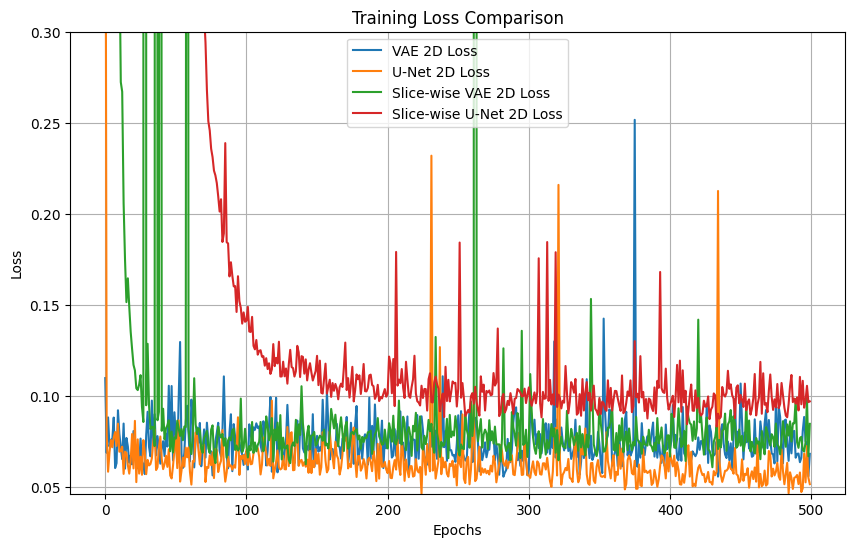

In [ ]:
series = [vae_loss, unet_loss, slice_vae_loss, slice_unet_loss]
series = [np.array(s, dtype=float) for s in series if s is not None and len(s) > 0]

plt.figure(figsize=(10,6))
plt.plot(vae_loss, label="VAE 2D Loss")
plt.plot(unet_loss, label="U-Net 2D Loss")
plt.plot(slice_vae_loss, label="Slice-wise VAE 2D Loss")
plt.plot(slice_unet_loss, label="Slice-wise U-Net 2D Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.ylim(0, 0.3)
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.savefig("out/loss_comparison.png")
plt.show()

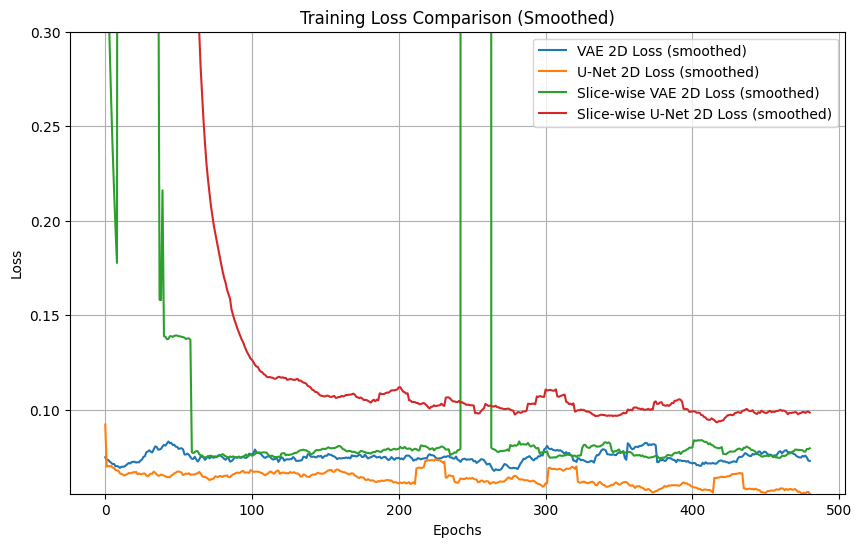

In [ ]:
def smooth(y, window=20):
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window)/window, mode='valid')

series = [vae_loss, unet_loss, slice_vae_loss, slice_unet_loss]
series = [np.array(s, dtype=float) for s in series if s is not None and len(s) > 0]

plt.figure(figsize=(10,6))
plt.plot(smooth(vae_loss), label="VAE 2D Loss (smoothed)")
plt.plot(smooth(unet_loss), label="U-Net 2D Loss (smoothed)")
plt.plot(smooth(slice_vae_loss), label="Slice-wise VAE 2D Loss (smoothed)")
plt.plot(smooth(slice_unet_loss), label="Slice-wise U-Net 2D Loss (smoothed)")
plt.ylim(0, 0.3)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Smoothed)")
plt.legend()
plt.grid()
plt.savefig("out/loss_comparison_smoothed.png")
plt.show()


### Import and Generate Slices

#### Setup

We load all models and data again so this can be run seperatly from main training loop

In [15]:
test_images = 5

# Same split as during training 
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


We load the same models (So we don't have to run everything over before this)

In [16]:
vae = VAE(latent_dim=64).to(device)
vae.load_state_dict(torch.load("out/vae_models/2d_vae_model.pt"))

unet = UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)
unet.load_state_dict(torch.load("out/unet_models/2d_unet_model.pt"))

slice_vae = [VAE(latent_dim=64).to(device) for _ in range(193)]
slice_unet = [UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device) for _ in range(193)]
for i in range(193):
    slice_vae[i].load_state_dict(torch.load(f"out/vae_models/multi/2d_vae_model_slice_{i}.pt"))
    slice_unet[i].load_state_dict(torch.load(f"out/unet_models/multi/2d_unet_model_slice_{i}.pt"))

#### Import and predict 5 random slices

Displaying results for test image 87, slice 75


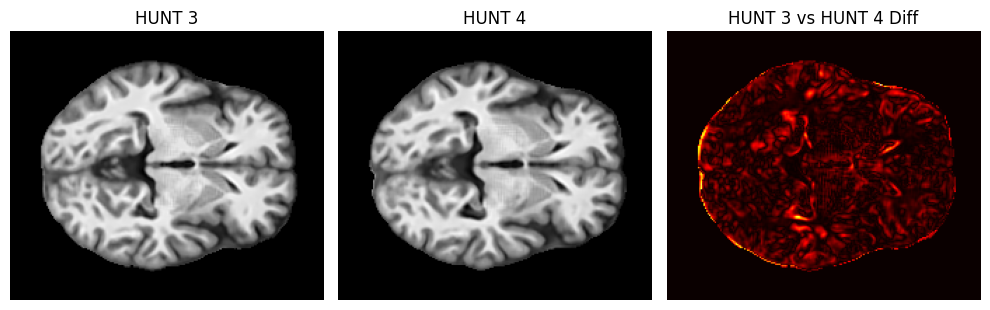

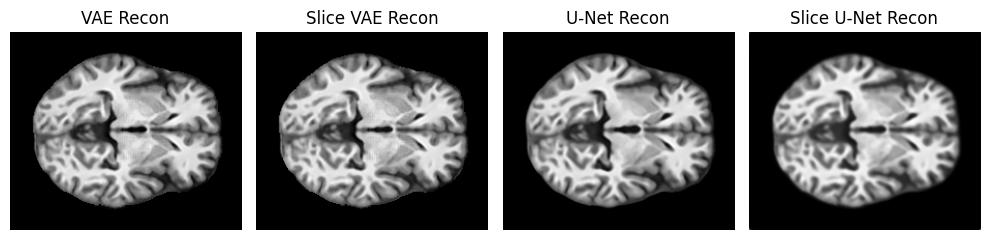

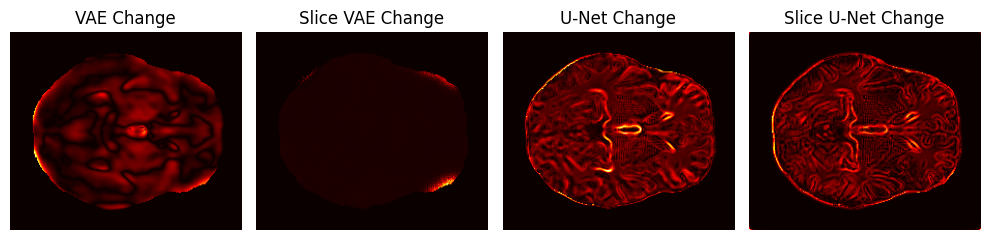

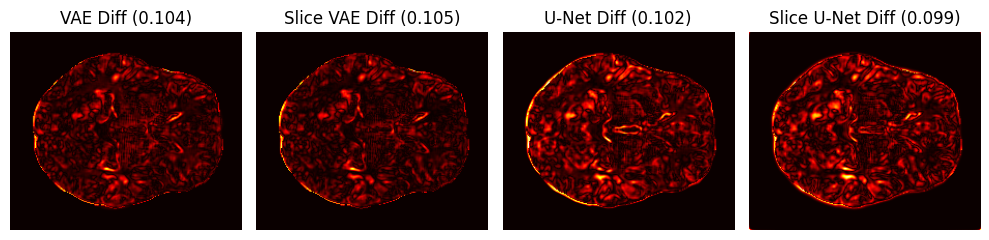

Displaying results for test image 62, slice 83


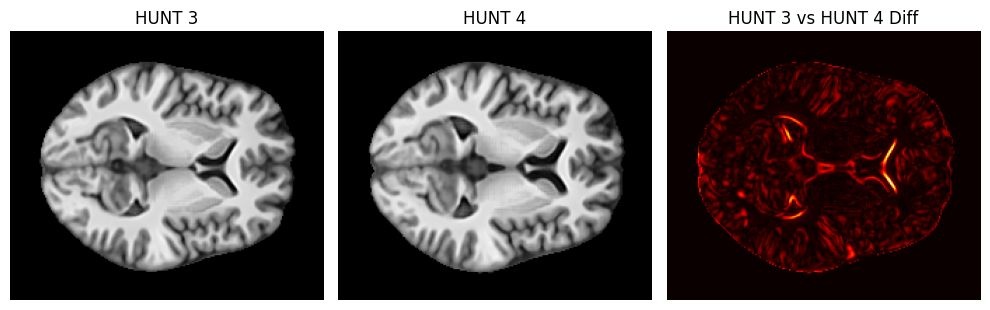

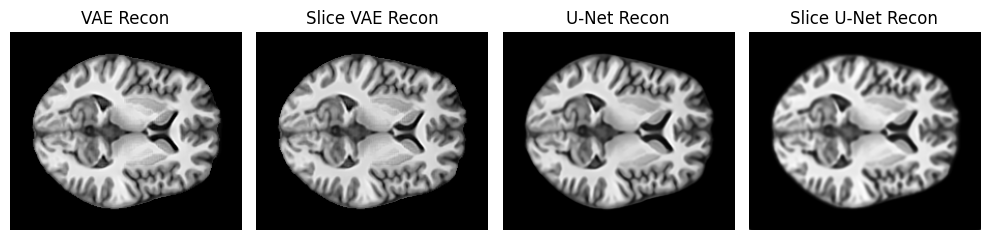

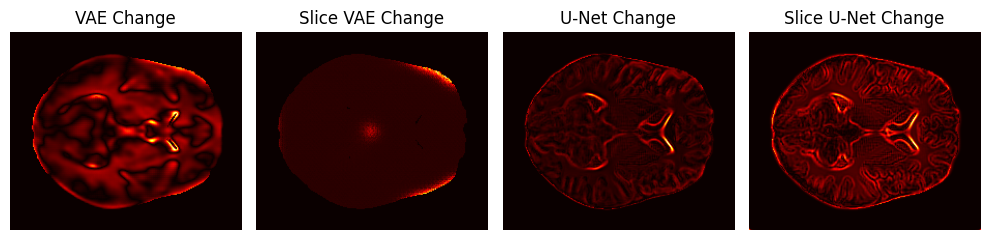

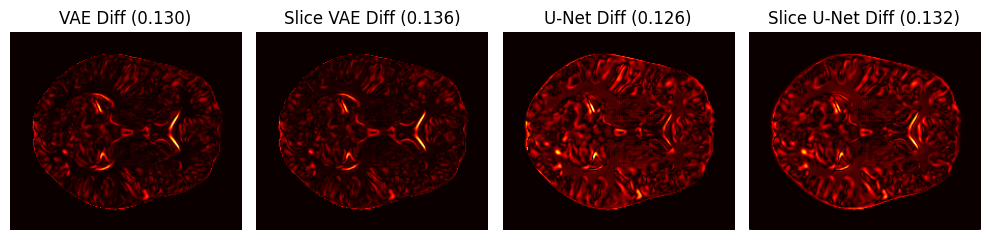

Displaying results for test image 71, slice 172


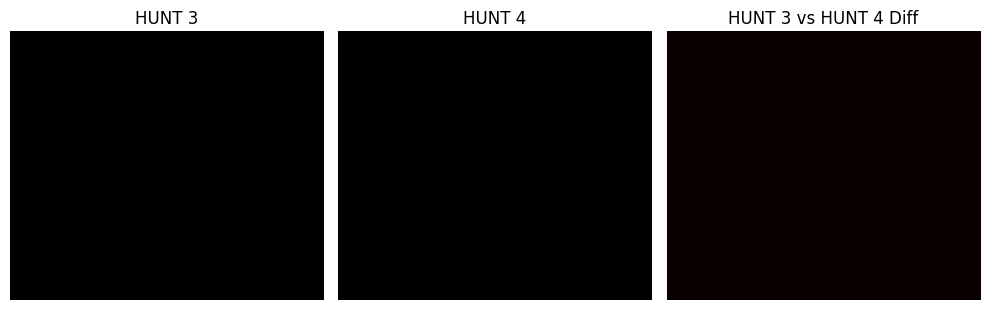

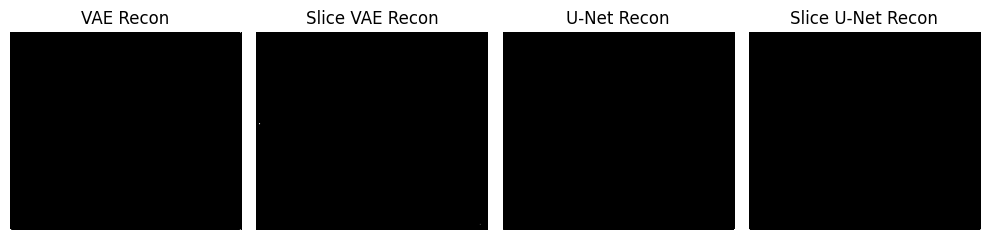

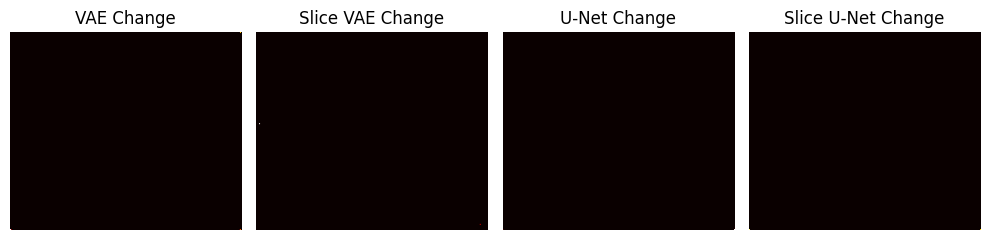

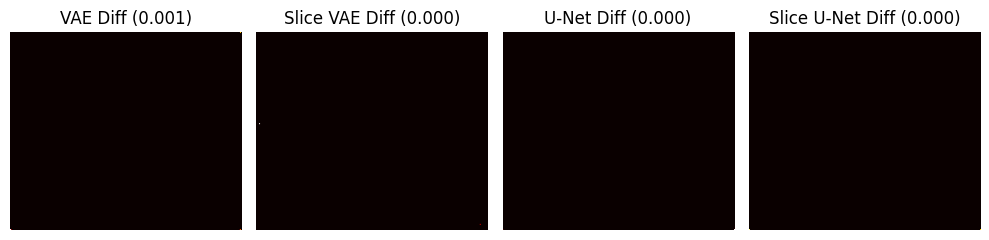

Displaying results for test image 130, slice 103


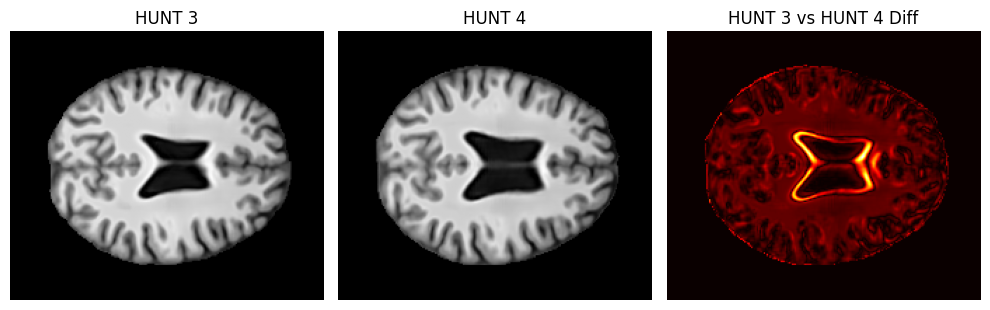

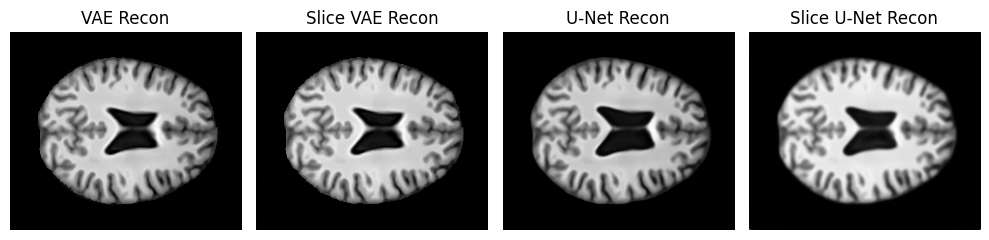

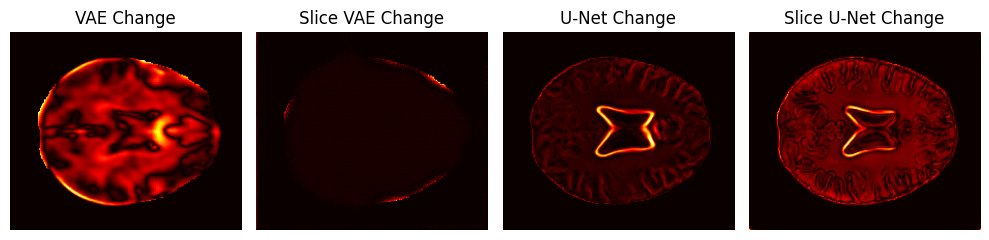

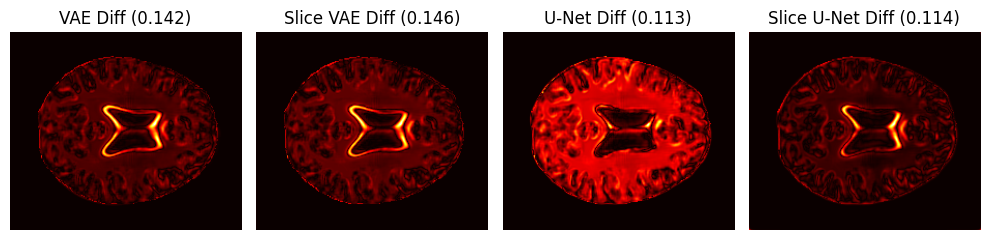

Displaying results for test image 104, slice 81


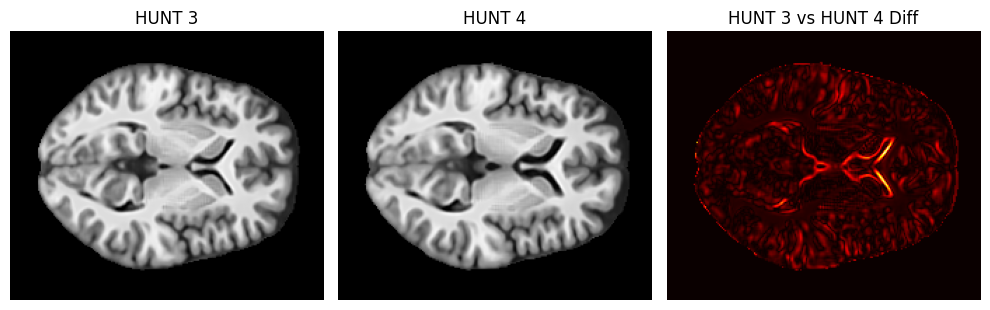

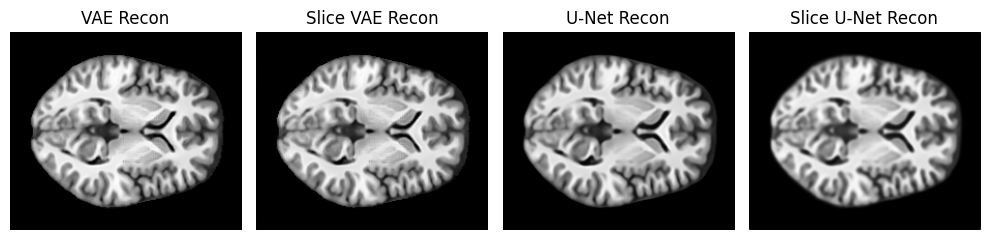

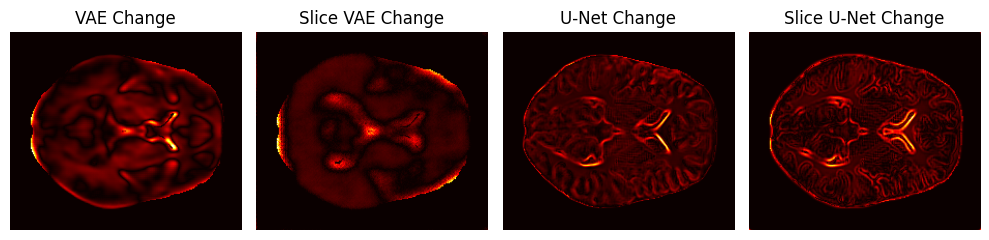

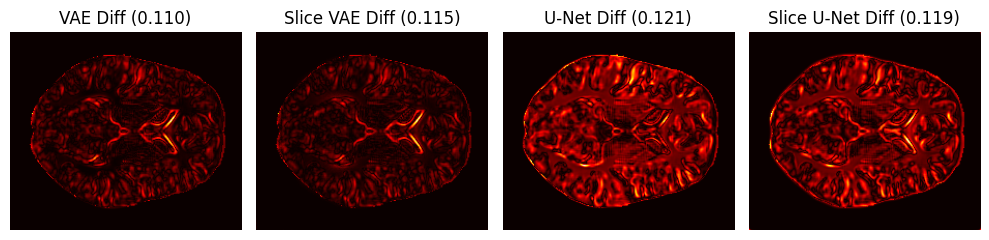

In [27]:
for i in range(test_images):
    slice = random.randint(0, 192)
    candidate = random.randint(0, len(test_pairs)-1)
    x_num, y_num = data_loader.get_slice(data_path=test_pairs[candidate][0], crop_size=(192, 224), index=slice), data_loader.get_slice(data_path=test_pairs[candidate][1], crop_size=(192, 224), index=slice)
    x = data_loader.to_torch_img(x_num, device)
    y = data_loader.to_torch_img(y_num, device)

    vae_recon_tensor, vae_mu, vae_longvar = vae(x)
    unet_recon_tensor, unet_mu, unet_longvar = unet(x)

    slice_vae_recon_tensor, slice_vae_mu, slice_vae_longvar = slice_vae[slice](x)
    slice_unet_recon_tensor, slice_unet_mu, slice_unet_longvar = slice_unet[slice](x)

    # Convert Tensor reconstructions to numpy for display
    vae_recon = data_loader.to_numpy_img(vae_recon_tensor)
    unet_recon = data_loader.to_numpy_img(unet_recon_tensor)
    slice_vae_recon = data_loader.to_numpy_img(slice_vae_recon_tensor)
    slice_unet_recon = data_loader.to_numpy_img(slice_unet_recon_tensor)

    # How much the models change from the input
    vae_change = np.abs(vae_recon - x_num)
    unet_change = np.abs(unet_recon - x_num)
    slice_vae_change = np.abs(slice_vae_recon - x_num)
    slice_unet_change = np.abs(slice_unet_recon - x_num)

    # Difference between reconstructions and ground truth
    vae_diff = np.abs(vae_recon - y_num)
    unet_diff = np.abs(unet_recon - y_num)
    slice_vae_diff = np.abs(slice_vae_recon - y_num)
    slice_unet_diff = np.abs(slice_unet_recon - y_num)
    hunt_diff = np.abs(x_num - y_num)

    # Prediction errors (SSIM+L1)
    vae_pred_error = ssim_L1_2d_loss(vae_recon_tensor, y, vae_mu, vae_longvar).item()
    unet_pred_error = ssim_L1_2d_loss(unet_recon_tensor, y, unet_mu, unet_longvar).item()
    slice_vae_pred_error = ssim_L1_2d_loss(slice_vae_recon_tensor, y, slice_vae_mu, slice_vae_longvar).item()
    slice_unet_pred_error = ssim_L1_2d_loss(slice_unet_recon_tensor, y, slice_unet_mu, slice_unet_longvar).item()

    print(f"Displaying results for test image {candidate}, slice {slice}")

    # Hunt 3, Hunt 4, and the difference between them
    data_loader.display_slices(
        slices=[x_num, y_num, hunt_diff],
        slice_labels=["HUNT 3", "HUNT 4", "HUNT 3 vs HUNT 4 Diff"],
        slice_colors=["gray", "gray", "hot"]
    )

    # The four models’ outputs
    data_loader.display_slices(
        slices=[vae_recon, slice_vae_recon, unet_recon, slice_unet_recon],
        slice_labels=["VAE Recon", "Slice VAE Recon", "U-Net Recon", "Slice U-Net Recon"],
        slice_colors=["gray", "gray", "gray", "gray"]
    )

    # The four models’ change from HUNT 3
    data_loader.display_slices(
        slices=[vae_change, slice_vae_change, unet_change, slice_unet_change],
        slice_labels=["VAE Change", "Slice VAE Change", "U-Net Change", "Slice U-Net Change"],
        slice_colors=["hot", "hot", "hot", "hot"]
    )

    # The four models’ difference from HUNT 4
    data_loader.display_slices(
        slices=[vae_diff, slice_vae_diff, unet_diff, slice_unet_diff],
        slice_labels=[
            f"VAE Diff ({vae_pred_error:.3f})",
            f"Slice VAE Diff ({slice_vae_pred_error:.3f})",
            f"U-Net Diff ({unet_pred_error:.3f})",
            f"Slice U-Net Diff ({slice_unet_pred_error:.3f})"
        ],
        slice_colors=["hot", "hot", "hot", "hot"]
    )